# HOMEWORK 1: AI ASSISTED PYTHON PROGRAMMING

**Due date: Midnight 10/13/2025**

In this homework, you are encouraged to use an AI assist to solve the problem.

Below, you will find the sequential model that we discussed in class. You may recall that species S2 is convex, it rises and then declines.

**Your assignment**
1. *Implementation* Write a function that finds values of k1 and k2 such that S2 peaks at a time. Remember that you need to document the function arguments and result and describe what it does. You also need at least one test. You should try to make the algorithm efficient. Remember to include a test for the values returned (e.g., returns floats).
2. *Verfication of Results*. Simulate with values found by your test case to ensure the algorithm's correct operation.
3. *Analysis*. Use the function you developed in (1) to simulate for a peak times of 1s, 2s, 3s. How are k1, k2 being changed to move the peak to be later in time? Why?


**Rubric (100 pts)**
* Q1 (30 pt): Implementation: documented, readable, has tests, passes tests.
* Q2 (50 pt): Verification. Demonstrates that desired peak time is achieved with the k1, k2 produced by the function.
* Q3 (20 pt): Analysis. Correctly identifies the trend in values of k1, k2.


**Homework submission**
* Create a folder in ``Student Folders`` in the class Google Drive.
* Set permissions for so that it is restricted to the instructors and the TA.
* Make a copy of this notebook and put it in the folder (with the same permissions as the folder)
* Answer the questions in the sections of the notebook

In [ ]:
try:
    import tellurium as te
except:
    !pip install -q tellurium
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, Tuple

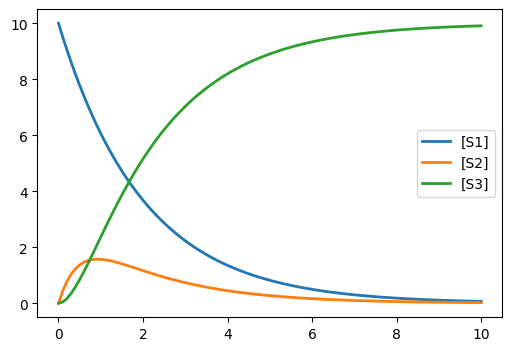

In [ ]:
def getModel(k1, k2):
    return f"""
    S1 -> S2; k1*S1
    S2 -> S3; k2*S2

    S1 = 10
    S2 = 0
    k1 = {k1} # Adjust this value
    k2 = {k2} # Adjust this value
    """
rr = te.loada(getModel(k1=0.5, k2=2))
data = rr.simulate(0, 10, 100)
rr.plot()

# Q1: Implementation

AI prompt inserted: Write a function that finds values of k1 and k2 such that S2 peaks at a time. Remember that you need to document the function arguments and result and describe what it does. You also need at least one test. You should try to make the algorithm efficient. Remember to include a test for the values returned (e.g., returns floats).

In [ ]:
import scipy.optimize as opt

def find_k1_k2_for_peak_time(peak_time: float) -> Tuple[float, float]:
    """
    Finds k1 and k2 values for the given peak time of species S2 in sequential model.

    The model is:
    S1 -> S2; k1*S1
    S2 -> S3; k2*S2

    Initial conditions: S1=10, S2=0, S3=0.

    Args:
        peak_time: The desired time at which S2 concentration peaks.

    Returns:
        A tuple containing the found k1 and k2 values.
    """

    # The concentration of S2 over time is given by the solution to the differential equations:
      # dS1/dt = -k1*S1
      # dS2/dt = k1*S1 - k2*S2
      # dS3/dt = k2*S2
      # With initial conditions S1(0)=10, S2(0)=0, S3(0)=0.
      # The solution for S2(t) is:
      # S2(t) = 10 * k1 / (k2 - k1) * (exp(-k1*t) - exp(-k2*t))  if k1 != k2
      # S2(t) = 10 * k1 * t * exp(-k1*t) if k1 == k2

    # To find the peak time, we take the derivative of S2(t) with respect to t and set it to zero.
      # For k1 != k2:
        # dS2/dt = 10 * k1 / (k2 - k1) * (-k1*exp(-k1*t) + k2*exp(-k2*t)) = 0
        # -k1*exp(-k1*t) + k2*exp(-k2*t) = 0
        # k2*exp(-k2*t) = k1*exp(-k1*t)
        # k2/k1 = exp(-k1*t) / exp(-k2*t) = exp((k2 - k1)*t)
        # ln(k2/k1) = (k2 - k1)*t
        # t_peak = ln(k2/k1) / (k2 - k1)

      # For k1 == k2:
        # dS2/dt = 10 * k1 * (exp(-k1*t) - k1*t*exp(-k1*t)) = 0
        # exp(-k1*t) * (1 - k1*t) = 0
        # 1 - k1*t = 0
        # t_peak = 1/k1

    # We want to find k1 and k2 such that t_peak = peak_time.
    # Let's assume a fixed ratio between k1 and k2 or some other relationship.

    # Numerical optimizer to find the best values for k1 and k2.
    # Calculates the difference in peak_times from k values and compares it to the desired_peak_time.
    # The best k1 and k2 values will resutlt the smallest difference from the peak_t and desired_peak_time.
    def peak_time_difference(k, desired_peak_time):
        k1, k2 = k
        if k1 <= 0 or k2 <= 0:
            return np.inf # Avoid non-positives

        if np.isclose(k1, k2):
             # Handle the case where k1 is very close to k2 causing a divison by 0
            peak_t = 1/k1
        else:
             # Ensures k2 > k1 for ln(k2/k1) to be positive and peak time to be positive
            if k2 <= k1:
                 return np.inf
            peak_t = np.log(k2 / k1) / (k2 - k1)

        return abs(peak_t - desired_peak_time)


    # We need an initial guess for k1 and k2. Let's try adjusting this based on the trend observed.
    # For longer peak times, k1 and k2 are smaller. Let's try smaller values for longer peak times.
    initial_guess = [0.05, 0.2]

    # Use optimization to find k1 and k2 that minimize the peak time difference.
    # Note: Nelder-Mead is an optimizer method
    result = opt.minimize(peak_time_difference, initial_guess, args=(peak_time), method='Nelder-Mead')

    # If the results are sucessful then it will return k1 and k2 but if it can't run through the optimization it will show an error.
    if result.success:
        return result.x[0], result.x[1]
    else:
        raise RuntimeError(f"Optimization failed: {result.message}")

In [ ]:
# Input the a peak_time and print the results for the k values
test_peak_time = 1.10
k1_test, k2_test = find_k1_k2_for_peak_time(test_peak_time)

print(f"For a desired peak time of {test_peak_time}s, found k1 = {k1_test:.4f}, k2 = {k2_test:.4f}")

# Verify the returned types
assert isinstance(k1_test, (float, np.floating)), f"k1_test is not a float: {type(k1_test)}"
assert isinstance(k2_test, (float, np.floating)), f"k2_test is not a float: {type(k2_test)}"

For a desired peak time of 1.1s, found k1 = 0.1632, k2 = 2.7211


# Q2: Verification

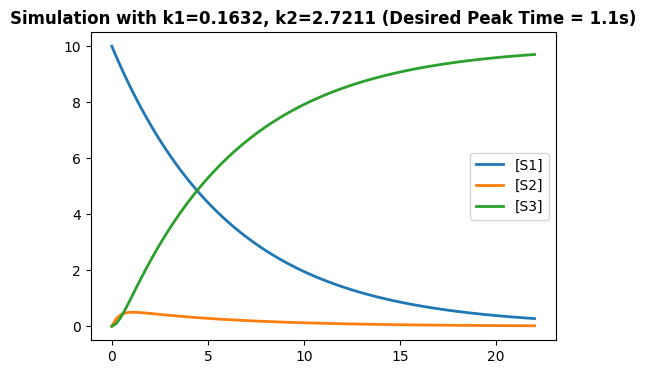

In [ ]:
# Verification: Simulate with test case values
# Use getModel from original function to create the antimony string
model_test = getModel(k1=k1_test, k2=k2_test)
rr_test = te.loada(model_test)

# Determine simulation end time based on desired peak time
# Simulate for a period expected to cover the peak and decline
simulation_end_time = test_peak_time * 20

data_test = rr_test.simulate(0, simulation_end_time, 100)
rr_test.plot(title=f"Simulation with k1={k1_test:.4f}, k2={k2_test:.4f} (Desired Peak Time = {test_peak_time}s)")

# Q3: Analysis



  Peak time = 1.0s: k1 = 0.1823, k2 = 2.9746
  Peak time = 2.0s: k1 = 0.1066, k2 = 1.3909
  Peak time = 3.0s: k1 = 0.0824, k2 = 0.8667


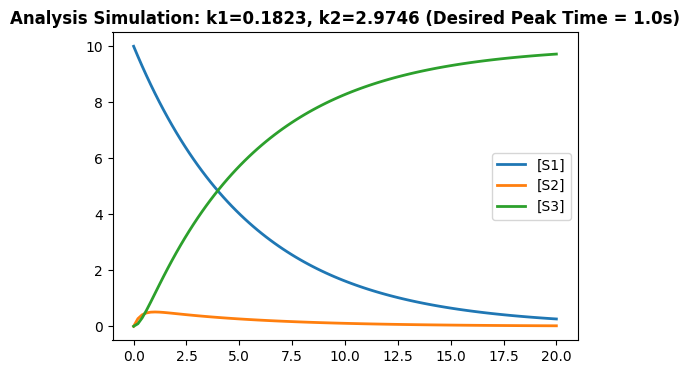

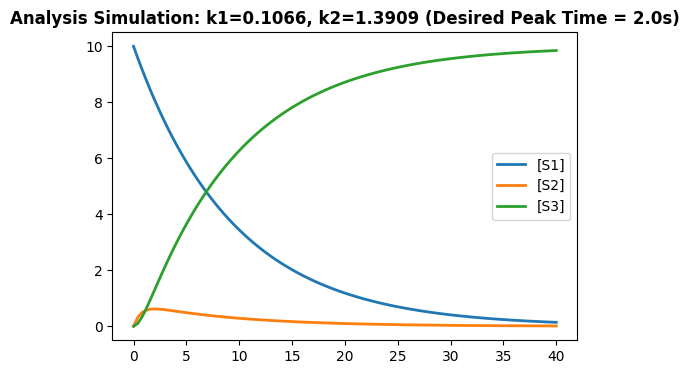

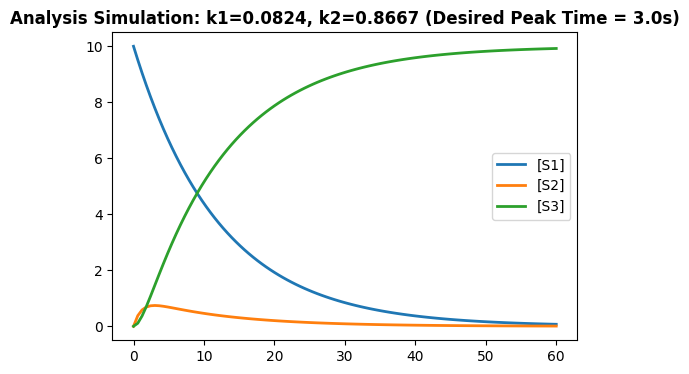

In [ ]:
# Calculate the k values and graph S2 at the peak times at 1s, 2s, and 3s.
peak_times_for_analysis = [1.0, 2.0, 3.0]
k_values = {} # Stores the k1 and k2 valyes for each peak

for pt in peak_times_for_analysis:
        k1_an, k2_an = find_k1_k2_for_peak_time(pt)
        k_values[pt] = (k1_an, k2_an)
        print(f"  Peak time = {pt}s: k1 = {k1_an:.4f}, k2 = {k2_an:.4f}")

for pt, (k1_an, k2_an) in k_values.items():
    rr_an = te.loada(getModel(k1=k1_an, k2=k2_an))
    data_an = rr_an.simulate(0, pt * 20, 100) # Simulate up to 20 times the peak time so we can include the peak time
    rr_an.plot(title=f"Analysis Simulation: k1={k1_an:.4f}, k2={k2_an:.4f} (Desired Peak Time = {pt}s)")


**Q3: As the peak for S2 moves to a later time, the values for k1 and k2 both start decreasing. This is because the slower the reation rate for S2 to be produced and consumed, the slower the peak happens. The peak overall occurs when the rate of formation matches the rate of removal so slowling down both causes the peak to happen later.**
